In [2]:
from pathlib import Path
import json
import random

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.saving import load_layer_metadata
from src.analysis.metamer import load_model_from_checkpoint

%matplotlib inline

plt.style.use("seaborn-v0_8")

REPO_ROOT = Path(".").resolve()
CONFIG_ROOT = REPO_ROOT / "configs"
EXPERIMENTS_ROOT = REPO_ROOT / "experiments"

# Three models for meeting figures: Lipschitz AlexNet w_max 0, w_max 10, Robust L2 3 AlexNet
MEETING_CONFIGS = [
    "configs/vision/lipsresnet50_v1/lipsresnet50_w_max_0_SGD.json",
    "configs/vision/lipsresnet50_v1/lipsresnet50_w_max_1_SGD.json",
    "configs/vision/robust_v1/resnet50_l2_3_robust.json",
]


def load_config(path: str) -> dict:
    with open(REPO_ROOT / path, "r") as f:
        return json.load(f)


def config_to_exp_root(cfg_path: str) -> Path:
    """Map a config path to its experiment root (matches training & metamer scripts)."""
    config_path = (REPO_ROOT / cfg_path).resolve()
    try:
        rel = config_path.relative_to(CONFIG_ROOT)
        return EXPERIMENTS_ROOT / rel.with_suffix("")
    except ValueError:
        return EXPERIMENTS_ROOT / config_path.stem


def meeting_model_label(cfg_path: str) -> str:
    """Return display label for the three meeting-figure models."""
    cfg = load_config(cfg_path)
    model_name = cfg.get("model_name", "")
    hparams = cfg.get("hparams", {})
    if model_name.startswith("lipsalexnet"):
        w_max = float(hparams.get("w_max", 0))
        return f"Lipschitz AlexNet\nw_max={w_max:g}"
    if model_name == "robustalexnet":
        return "Robust AlexNet\nL2 ε=3"
    return cfg_path




# Meeting Figures

This notebook produces three figures for the meeting:

1. **Lipschitz bound vs. no-attack accuracy** — Lipschitz AlexNet w_max=0, w_max=10, and Robust L2 ε=3 AlexNet.
2. **Attack size vs. average confidence and vs. accuracy** — Same three models; data from precomputed adversarial CSVs (`scripts/attack_models.py` run at multiple ε).
3. **Metamer display** — One row per model (same three), columns = natural image + metamers at fake-ReLU layers.

In [3]:
# --- Metrics loading (Weights & Biases for Lipschitz; in-notebook for Robust) ---

def _maybe_scalar(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().cpu().item())
    if isinstance(x, (int, float)):
        return float(x)
    return None


def find_wandb_summary_for_experiment(exp_root: Path) -> Path | None:
    """Locate the wandb summary JSON for a given experiment root.

    We expect a text file at
        <exp_root>/wandb_run_id.txt
    that stores the wandb run id (e.g. "kyifb10r").  In the top-level
    repo `wandb` directory we then look for a matching folder like
        wandb/run-20260302_120351-kyifb10r/
    and inside it
        files/wandb-summary.json
    """
    run_id_file = exp_root / "wandb_run_id.txt"
    if not run_id_file.exists():
        return None

    run_id = run_id_file.read_text().strip()
    if not run_id:
        return None

    wandb_root = REPO_ROOT / "wandb"
    if not wandb_root.exists():
        return None

    # There may be a date/time prefix before the run id; glob for it.
    candidates = sorted(wandb_root.glob(f"run-*-{run_id}"))
    if not candidates:
        return None

    run_dir = candidates[-1]
    summary_path = run_dir / "files" / "wandb-summary.json"
    return summary_path if summary_path.exists() else None


def load_metrics_from_wandb(summary_path: Path) -> tuple[float | None, float | None]:
    with open(summary_path, "r") as f:
        data = json.load(f)

    # Prefer the more explicit key if present, fall back to top-1 accuracy
    acc = data.get("val/accuracy")
    if acc is None:
        acc = data.get("val/top1_acc")

    lips_bound = data.get("val/lips_bound")

    return _maybe_scalar(acc), _maybe_scalar(lips_bound)


# Robust checkpoint for in-notebook Lipschitz bound (clean accuracy comes from adversarial epsilon=0 CSV).
ROBUST_CKPT = REPO_ROOT / "model_analysis_folders/visual_networks/pytorch_checkpoints/resnet50_imagenet_l2_3_0_robustness.pt"


def clean_accuracy_from_adv_csv(cfg_path: str) -> float | None:
    """Clean (no-attack) accuracy = mean(is_correct) from adversarial run with epsilon=0."""
    adv_dir = config_to_exp_root(cfg_path) / "adversarial"
    # attack_models.py uses epsilon_to_filename_token: format(eps,"g").replace(".","p") -> 0 -> "0"
    csv_path = adv_dir / "adversarial_l2_eps_0.csv"
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    if "is_correct" not in df.columns or df.empty:
        return None
    return float(df["is_correct"].mean())


def build_figure1_table(device: str = "cuda") -> pd.DataFrame:
    """Build table of (lips_bound, val_accuracy) for MEETING_CONFIGS for Figure 1.
    Clean accuracy for all three models comes from adversarial CSV with epsilon=0."""
    rows: list[dict] = []
    for cfg_path in MEETING_CONFIGS:
        cfg = load_config(cfg_path)
        model_name = cfg.get("model_name", "")
        label = meeting_model_label(cfg_path)
        exp_root = config_to_exp_root(cfg_path)

        val_acc = clean_accuracy_from_adv_csv(cfg_path)
        lips_bound = None

        if model_name.startswith("lipsalexnet"):
            summary_path = find_wandb_summary_for_experiment(exp_root)
            if summary_path is not None:
                _acc, lips_bound = load_metrics_from_wandb(summary_path)
        else:
            if ROBUST_CKPT.exists():
                model, _ = load_model_from_checkpoint(cfg_path, str(ROBUST_CKPT), device=device)
                lips_bound = float(model.get_lips_bound())

        rows.append({
            "config_path": cfg_path,
            "model_name": label,
            "val_accuracy": val_acc,
            "val_lips_bound": lips_bound,
        })
    return pd.DataFrame(rows)


In [4]:
# Figure 1: Lipschitz bound vs. no-attack accuracy (clean accuracy from adversarial epsilon=0 CSV)
fig1_df = build_figure1_table()
fig1_df

KeyError: 'state_dict'

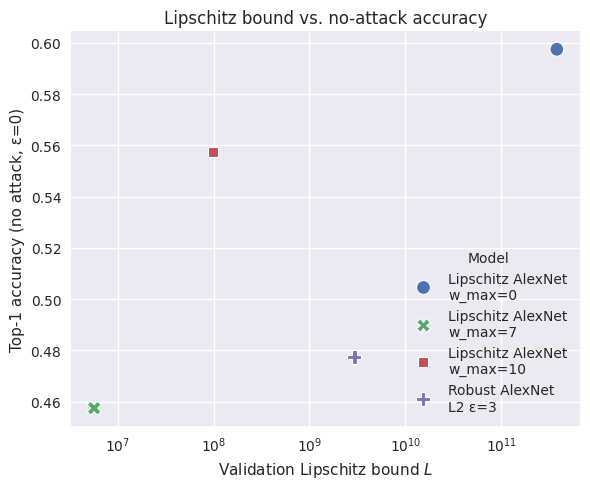

In [5]:
# Figure 1: Scatter — Lipschitz bound vs. no-attack accuracy
plot_df = fig1_df.dropna(subset=["val_accuracy", "val_lips_bound"]).copy()
if plot_df.empty:
    print("No data for Figure 1 (missing wandb summaries, epsilon=0 adversarial CSVs, or robust checkpoint).")
else:
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.scatterplot(
        data=plot_df,
        x="val_lips_bound",
        y="val_accuracy",
        hue="model_name",
        style="model_name",
        s=100,
        ax=ax,
    )
    if plot_df["val_lips_bound"].max() / (plot_df["val_lips_bound"].min() + 1e-30) > 10:
        ax.set_xscale("log")
    ax.set_xlabel("Validation Lipschitz bound $L$")
    ax.set_ylabel("Top-1 accuracy (no attack, ε=0)")
    ax.set_title("Lipschitz bound vs. no-attack accuracy")
    ax.legend(title="Model")
    plt.tight_layout()
    plt.show()

## Figure 2: Attack size vs. accuracy and vs. average confidence

Load precomputed adversarial results from `experiments/.../adversarial/`. Run `scripts/attack_models.py` for each of the three configs at several ε values (e.g. 0, 0.5, 1, 2, 3) so that `adversarial_l2_eps_*.csv` exist.

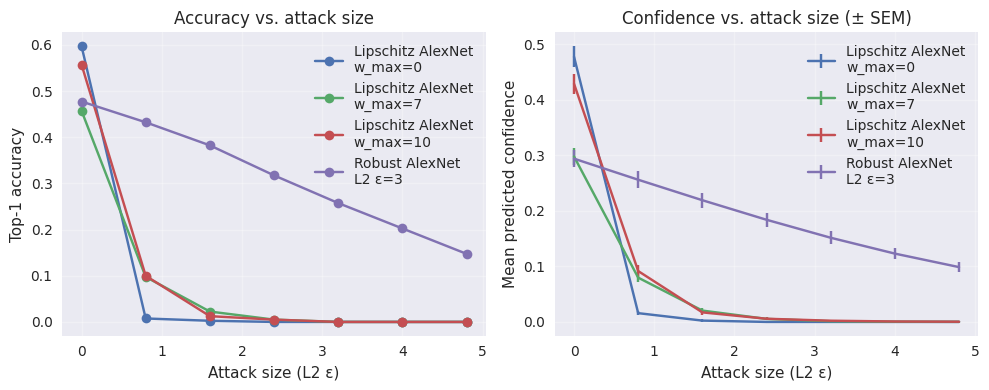

In [6]:
import re

def get_attack_size_from_csv_name(csv_name: str) -> float | None:
    """
    Parse L2 attack size (epsilon) from adversarial_l2_eps_X.csv,
    where X can be 0p8 (→ 0.8), 4p8 (→ 4.8), or similar.

    Supported patterns:
      - adversarial_l2_eps_{number}.csv (e.g., adversarial_l2_eps_0p8.csv)
      - adversarial_l2_eps_{number}plwAW.csv (rare alternative)
    """
    # Accept both 0p8 and 0.8 token styles to be robust
    pattern = r"^adversarial_l2_eps_([-+]?[0-9]*\.?[0-9]+|[0-9]+p[0-9]+)(?:plwAW)?\.csv$"
    m = re.match(pattern, csv_name)
    if not m:
        return None
    token = m.group(1)
    # Try parsing forms like 0p8 → 0.8, and also direct floats
    try:
        if "p" in token:
            return float(token.replace("p", "."))
        else:
            return float(token)
    except Exception:
        return None

def load_attack_curves_per_config() -> dict[str, pd.DataFrame]:
    """
    For each MEETING_CONFIG, load all adversarial CSVs as per naming
    *including* those like adversarial_l2_eps_0p8.csv,
    and return a DataFrame per config with columns:
    epsilon, mean_confidence, sem_confidence, accuracy.
    """
    out = {}
    for cfg_path in MEETING_CONFIGS:
        adv_dir = config_to_exp_root(cfg_path) / "adversarial"
        if not adv_dir.exists():
            continue
        rows = []
        for csv_path in sorted(adv_dir.glob("adversarial_l2_eps_*.csv")):
            eps = get_attack_size_from_csv_name(csv_path.name)
            if eps is None:
                continue
            df = pd.read_csv(csv_path)
            # Support both older and new column names: "true_class_softmax"/"predicted_softmax"
            conf_col = None
            if "predicted_softmax" in df.columns:
                conf_col = "predicted_softmax"
            elif "true_class_softmax" in df.columns:
                conf_col = "true_class_softmax"
            else:
                continue
            if "is_correct" not in df.columns:
                continue
            n = len(df)
            mean_conf = df[conf_col].mean()
            sem_conf = df[conf_col].std() / (n ** 0.5) if n > 0 else 0.0
            acc = df["is_correct"].mean()
            rows.append({
                "epsilon": eps,
                "mean_confidence": mean_conf,
                "sem_confidence": sem_conf,
                "accuracy": acc,
            })
        if rows:
            out[cfg_path] = pd.DataFrame(rows).sort_values("epsilon").reset_index(drop=True)
    return out

attack_curves = load_attack_curves_per_config()
if not attack_curves:
    print("No adversarial CSVs found. Run scripts/attack_models.py for each config at several ε.")
else:
    fig, (ax_acc, ax_conf) = plt.subplots(1, 2, figsize=(10, 4))
    for cfg_path, df in attack_curves.items():
        label = meeting_model_label(cfg_path)
        ax_acc.plot(df["epsilon"], df["accuracy"], "o-", label=label)
        ax_conf.errorbar(
            df["epsilon"],
            df["mean_confidence"],
            yerr=df["sem_confidence"],
            capsize=3,
            label=label,
        )
    ax_acc.set_xlabel("Attack size (L2 ε)")
    ax_acc.set_ylabel("Top-1 accuracy")
    ax_acc.set_title("Accuracy vs. attack size")
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)
    ax_conf.set_xlabel("Attack size (L2 ε)")
    ax_conf.set_ylabel("Mean predicted confidence")
    ax_conf.set_title("Confidence vs. attack size (± SEM)")
    ax_conf.legend()
    ax_conf.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Figure 3: Metamer display

Load **locally saved metamers** for the same three models (Lipschitz w_max 0, w_max 10, Robust L2 3). Each row = one model; columns = natural image + metamers at successive fake-ReLU layers. One random ImageNet example is used per row across all layers.

In [7]:
ALEXNET_FAKE_RELU_LAYERS = [
    "relu0_fake_relu",
    "relu1_fake_relu",
    "relu2_fake_relu",
    "relu3_fake_relu",
    "relu4_fake_relu",
    "fc0_relu_fake_relu",
    "fc1_relu_fake_relu",
    "final"
]

RESNET_FAKE_RELU_LAYERS = [
    "conv1_relu1_fake_relu",
    "layer1_fake_relu",
    "layer2_fake_relu",
    "layer3_fake_relu",
    "layer4_fake_relu",
    "avgpool",
    "final"
]


def layer_dir_for_config(cfg_path: str, layer_name: str) -> Path:
    exp_root = config_to_exp_root(cfg_path)
    return exp_root / "metamers" / layer_name


def available_indices_for_layer(layer_dir: Path) -> list[int]:
    meta = load_layer_metadata(layer_dir)
    return sorted(meta.keys())


def choose_shared_sample_idx_for_all(config_paths: list[str], layer_names: list[str]) -> int:
    """Choose one sample index present in all layers of all configs."""
    all_idx_sets = []
    for cfg_path in config_paths:
        idx_sets = []
        for layer in layer_names:
            layer_dir = layer_dir_for_config(cfg_path, layer)
            indices = available_indices_for_layer(layer_dir)
            if not indices:
                continue
            idx_sets.append(set(indices))
        if not idx_sets:
            raise RuntimeError(f"No metamer indices found for config {cfg_path}")
        shared = set.intersection(*idx_sets)
        if not shared:
            shared = idx_sets[0]
        all_idx_sets.append(shared)
    if not all_idx_sets:
        raise RuntimeError("No metamer indices found for any config")
    shared_among_all = set.intersection(*all_idx_sets)
    if not shared_among_all:
        # fallback: just use any from the first config
        shared_among_all = all_idx_sets[0]
    return random.choice(sorted(shared_among_all))


def find_image_path(layer_dir: Path, sample_idx: int, kind: str) -> Path:
    """Find metamer or original PNG for a given sample index.

    kind: "metamer" or "original".
    """
    pattern = f"idx{sample_idx:04d}_*_{kind}.png"
    matches = sorted(layer_dir.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No {kind} image found in {layer_dir} for sample {sample_idx}")
    return matches[0]


def _clean_layer_label(layer_name: str) -> str:
    return layer_name.replace("_fake_relu", "").replace("_fakerelu", "")


def plot_metamer_grid(config_paths: list[str], layer_names: list[str], title: str):
    n_rows = len(config_paths)
    n_cols = 1 + len(layer_names)

    # Add extra width to the figure to allow space for row labels
    # Widen first column; set width_ratios to make the first (labels) column ~2x wider
    width_ratios = [1.35] + [1.0] * (n_cols - 1)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.3 * n_cols, 2.0 * n_rows),
        gridspec_kw={'width_ratios': width_ratios}
    )
    if n_rows == 1:
        axes = axes[None, :]

    # Always use the same sample_idx for every model
    sample_idx = choose_shared_sample_idx_for_all(config_paths, layer_names)

    for row, cfg_path in enumerate(config_paths):
        label = meeting_model_label(cfg_path)

        # First column: natural image from first layer directory
        first_layer_dir = layer_dir_for_config(cfg_path, layer_names[0])
        orig_path = find_image_path(first_layer_dir, sample_idx, "original")
        orig_img = plt.imread(orig_path)
        ax = axes[row, 0]
        ax.imshow(orig_img)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title("natural image")
        ax.set_ylabel(
            label,
            fontsize=10,
            rotation=0,
            labelpad=55,   # Increased label pad for more space
            va="center"
        )

        # Metamers
        for col, layer_name in enumerate(layer_names, start=1):
            layer_dir = layer_dir_for_config(cfg_path, layer_name)
            met_path = find_image_path(layer_dir, sample_idx, "metamer")
            met_img = plt.imread(met_path)
            ax = axes[row, col]
            ax.imshow(met_img)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(_clean_layer_label(layer_name))

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

## Data availability

- **Figure 1:** Lipschitz bounds from wandb summaries (`<exp_root>/wandb_run_id.txt` → `wandb/run-*-<id>/files/wandb-summary.json`). Robust bound computed in-notebook. Clean accuracy from `experiments/.../adversarial/adversarial_l2_eps_0.csv` (run `scripts/attack_models.py --epsilon 0` for each config).
- **Figure 2:** Adversarial CSVs under `experiments/vision/<config_stem>/adversarial/adversarial_l2_eps_*.csv` (run `scripts/attack_models.py` at several ε per config).
- **Figure 3:** Metamer PNGs under `experiments/vision/<config_stem>/metamers/<layer_name>/` (run `scripts/generate_metamers.py` for each config).

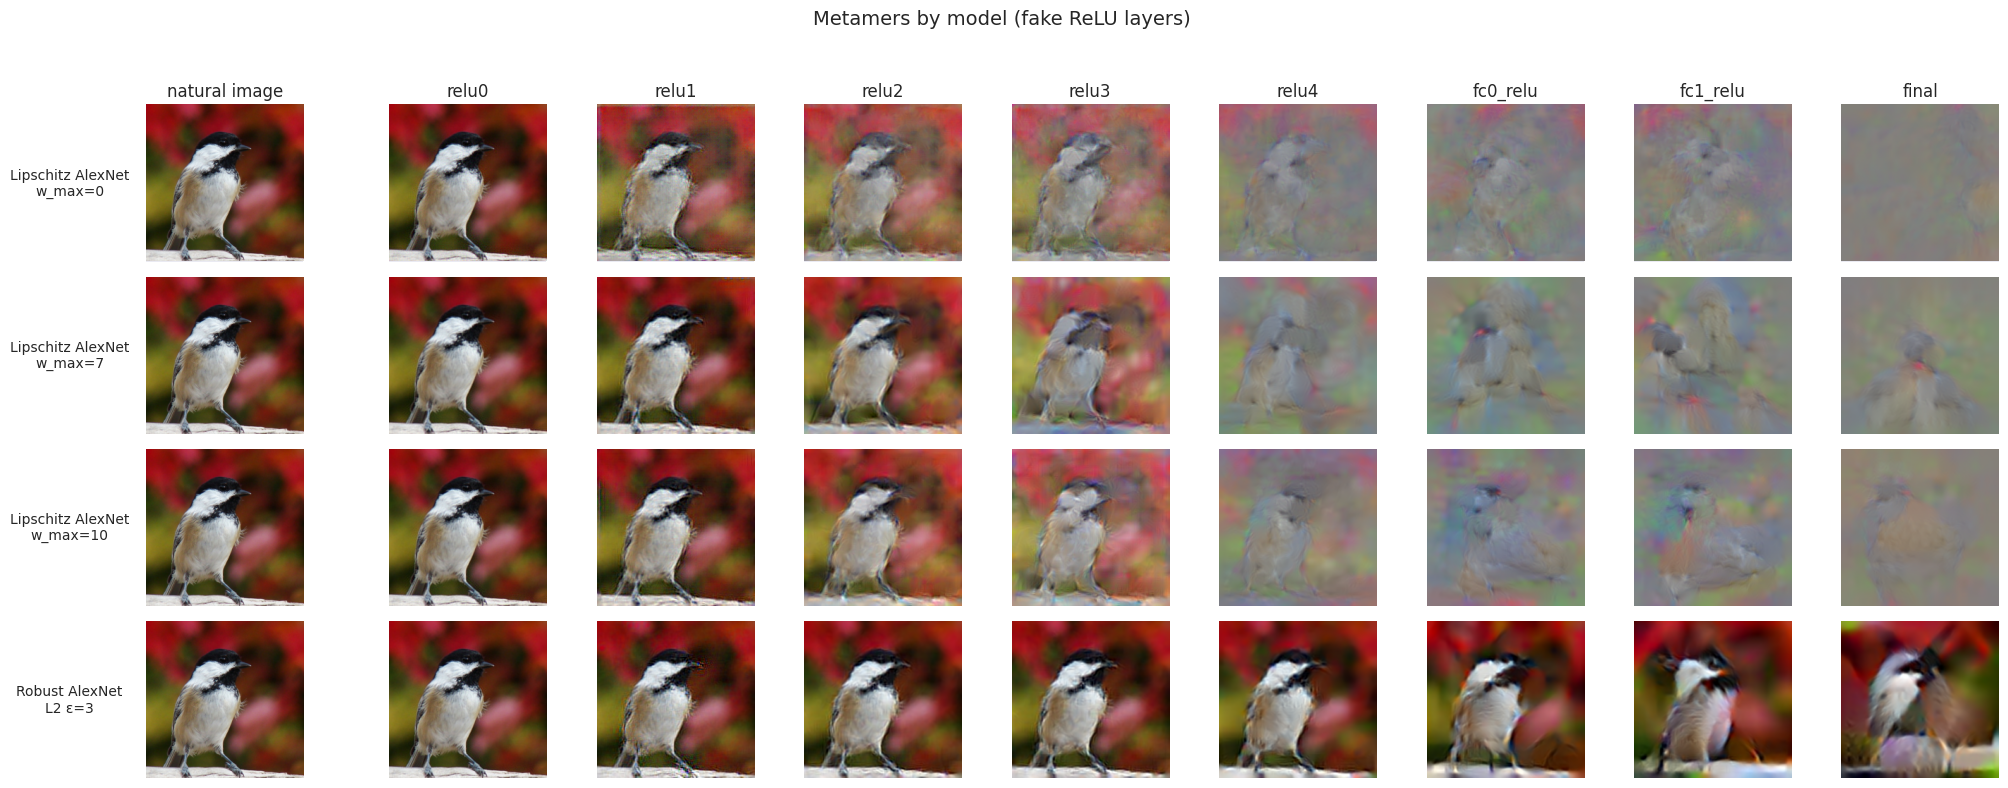

In [8]:
# Figure 3: Metamer grid for the same three models (fake ReLU layers)

plot_metamer_grid(
    config_paths=MEETING_CONFIGS,
    layer_names=ALEXNET_FAKE_RELU_LAYERS,
    title="Metamers by model (fake ReLU layers)",
)